绘图完成！图片已保存为 comparison_boxplot_dif_policy.pdf


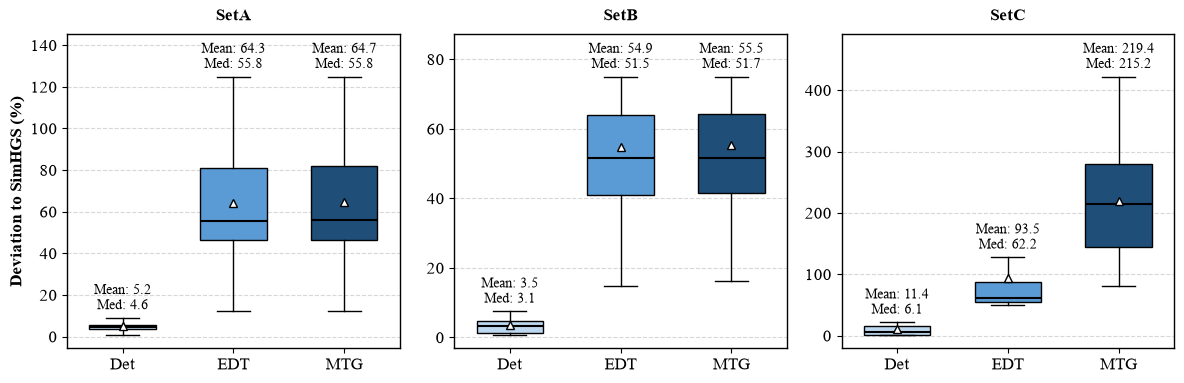

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_full_box_results():
    # ================= 1. 全局字体与风格设置 =================
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Times New Roman']
    plt.rcParams['axes.unicode_minus'] = False 
    
    plt.rcParams['font.size'] = 12
    plt.rcParams['axes.titlesize'] = 12  
    plt.rcParams['axes.labelsize'] = 12  
    plt.rcParams['xtick.labelsize'] = 12 
    plt.rcParams['ytick.labelsize'] = 12
    plt.rcParams['axes.linewidth'] = 1.0 

    # ================= 2. 数据读取与处理 =================
    file_path = 'baselineComparePlot.csv'
    
    try:
        df = pd.read_csv(file_path)
    except Exception as e:
        print(f"读取文件失败，尝试使用制表符分隔符... ({e})")
        df = pd.read_csv(file_path, sep='\t')

    df.columns = df.columns.str.strip()
    
    strategies = ['Det', 'EDT', 'MTG']
    base_col = 'SimHGS'
    
    for strategy in strategies:
        col_name = f'{strategy}_Gap'
        df[col_name] = (df[strategy] - df[base_col]) / df[base_col] * 100

    set_a = df[df['Instance Name'].str.endswith('_M')].copy()
    set_b = df[df['Instance Name'].str.endswith('_MD')].copy()
    set_c = df[df['Instance Name'].str.endswith('_X')].copy()
    
    datasets = [
        ('SetA', set_a),
        ('SetB', set_b),
        ('SetC', set_c)
    ]

    # ================= 3. 绘图参数设置 =================
    blue_colors = ['#BDD7EE', '#5B9BD5', '#1F4E79'] 
    THRESHOLD = 500 

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    
    # ================= 4. 循环绘图 =================
    for i, (title, data) in enumerate(datasets):
        ax = axes[i]
        
        if data.empty:
            ax.set_title(title)
            ax.text(0.5, 0.5, 'No Data', ha='center')
            continue
        
        plot_data = []
        stats_data = [] # 用于保存每个箱子的统计信息(均值, 中位数, 上须位置)
        
        for strategy in strategies:
            gap_col = f'{strategy}_Gap'
            series = data[gap_col].dropna()
            
            # 数据过滤：剔除 > 500% 的点 (接下来的统计和绘图均基于此过滤后的数据)
            series_filtered = series[series <= THRESHOLD]
            plot_data.append(series_filtered)
            
            # --- 计算剔除异常值后的平均值和中位值 ---
            if not series_filtered.empty:
                mean_val = series_filtered.mean()
                median_val = series_filtered.median()
                
                # 计算上触须(Upper Whisker)的位置，用于定位标注文字，防止文字和箱线图重叠
                q1 = series_filtered.quantile(0.25)
                q3 = series_filtered.quantile(0.75)
                iqr = q3 - q1
                whisker_data = series_filtered[series_filtered <= q3 + 1.5 * iqr]
                upper_whisker = whisker_data.max() if not whisker_data.empty else series_filtered.max()
                
                stats_data.append((mean_val, median_val, upper_whisker))
            else:
                stats_data.append((float('nan'), float('nan'), float('nan')))

        # 绘制箱线图
        bplot = ax.boxplot(plot_data,
                           patch_artist=True,
                           tick_labels=strategies,
                           showfliers=False, 
                           showmeans=True, 
                           meanprops={'marker':'^', 'markerfacecolor':'white', 'markeredgecolor':'black', 'markersize': 6}, # 设置均值点样式(白色三角)
                           widths=0.6,
                           medianprops={'color': 'black', 'linewidth': 1.5}) 
        
        # 填充颜色 (蓝色渐变)
        for patch, color in zip(bplot['boxes'], blue_colors):
            patch.set_facecolor(color)       
            patch.set_edgecolor('black')     
            patch.set_linewidth(1.0)         

        # --- 添加均值和中位值标注文本 ---
        y_min, y_max = ax.get_ylim()
        y_range = y_max - y_min
        
        # 动态调高Y轴上限，给顶部的标注文本留出空间 (增加 15% 的空间)
        valid_whiskers = [s[2] for s in stats_data if not pd.isna(s[2])]
        if valid_whiskers:
            new_ymax = max(y_max, max(valid_whiskers) + y_range * 0.15)
            ax.set_ylim(y_min, new_ymax)
            
            for j, (mean_val, median_val, upper_whisker) in enumerate(stats_data):
                if pd.isna(mean_val): continue
                
                # 标注文本格式
                text_str = f"Mean: {mean_val:.1f}\nMed: {median_val:.1f}"
                
                # 在对应箱子的上触须上方绘制文字
                ax.text(j + 1, upper_whisker + (new_ymax - y_min) * 0.02, text_str, 
                        ha='center', va='bottom', fontsize=10, linespacing=1.2, color='black')

        # 图表装饰
        ax.set_title(title, fontweight='bold', pad=10)
        ax.grid(True, axis='y', linestyle='--', alpha=0.5, zorder=0)
        
        if i == 0:
            ax.set_ylabel('Deviation to SimHGS (%)', fontweight='bold')

    # ================= 5. 保存与显示 =================
    plt.tight_layout()
    
    save_name = 'comparison_boxplot_dif_policy.pdf'
    plt.savefig(save_name, dpi=300, bbox_inches='tight')
    print(f"绘图完成！图片已保存为 {save_name}")
    
    plt.show()

if __name__ == "__main__":
    plot_full_box_results()

绘图完成！图片已保存为 5.baseline_sensitivity_grouped_bar.pdf


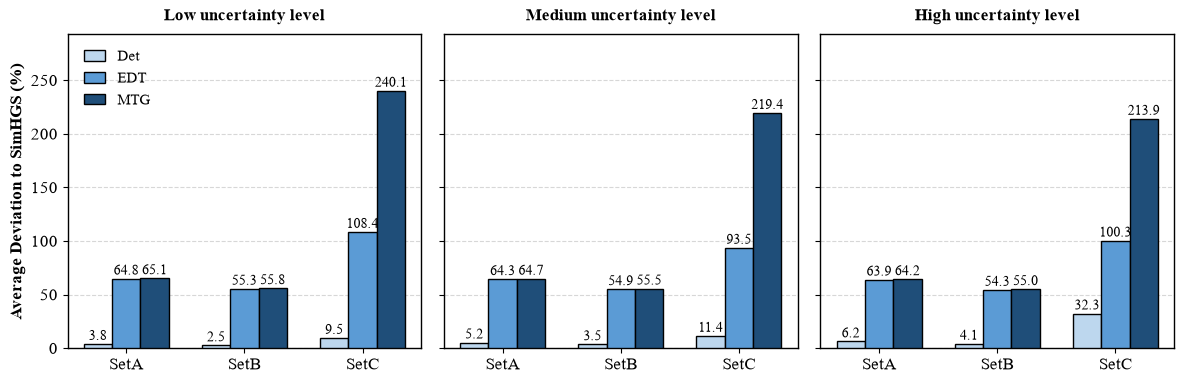

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def read_and_process(file_path):
    """
    读取单个csv文件，并计算 Det/EDD/MAG 相对 SimHGS 的 gap (%)
    然后按 SetA / SetB / SetC 分组，返回每组的平均值
    """
    try:
        df = pd.read_csv(file_path)
    except Exception as e:
        print(f"读取文件失败，尝试使用制表符分隔符... ({e})")
        df = pd.read_csv(file_path, sep='\t')

    df.columns = df.columns.str.strip()

    strategies = ['Det', 'EDT', 'MTG']
    base_col = 'SimHGS'

    # 计算 gap
    for strategy in strategies:
        col_name = f'{strategy}_Gap'
        df[col_name] = (df[strategy] - df[base_col]) / df[base_col] * 100

    # 按实例集划分
    set_a = df[df['Instance Name'].str.endswith('_M')].copy()
    set_b = df[df['Instance Name'].str.endswith('_MD')].copy()
    set_c = df[df['Instance Name'].str.endswith('_X')].copy()

    dataset_map = {
        'SetA': set_a,
        'SetB': set_b,
        'SetC': set_c
    }

    # 计算每个 set 下各策略的平均 gap
    results = {}
    for set_name, data in dataset_map.items():
        results[set_name] = {}
        for strategy in strategies:
            gap_col = f'{strategy}_Gap'
            series = data[gap_col].dropna()

            # 如需和你之前箱线图一致，可继续保留这个阈值过滤
            THRESHOLD = 500
            series_filtered = series[series <= THRESHOLD]

            if not series_filtered.empty:
                results[set_name][strategy] = series_filtered.mean()
            else:
                results[set_name][strategy] = np.nan

    return results


def plot_grouped_bar_results():
    # ================= 1. 全局字体与风格设置 =================
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Times New Roman']
    plt.rcParams['axes.unicode_minus'] = False

    plt.rcParams['font.size'] = 12
    plt.rcParams['axes.titlesize'] = 12
    plt.rcParams['axes.labelsize'] = 12
    plt.rcParams['xtick.labelsize'] = 12
    plt.rcParams['ytick.labelsize'] = 12
    plt.rcParams['axes.linewidth'] = 1.0

    # ================= 2. 文件路径 =================
    file_low = 'result_baseLow.csv'
    file_med = 'result_baseline.csv'
    file_high = 'result_baseHigh.csv'

    # ================= 3. 数据读取与处理 =================
    low_results = read_and_process(file_low)
    med_results = read_and_process(file_med)
    high_results = read_and_process(file_high)

    all_results = {
        r'Low uncertainty level': low_results,
        r'Medium uncertainty level': med_results,
        r'High uncertainty level': high_results
    }

    strategies = ['Det', 'EDT', 'MTG']
    sets = ['SetA', 'SetB', 'SetC']

    # 蓝色系配色，沿用你原来的风格
    blue_colors = ['#BDD7EE', '#5B9BD5', '#1F4E79']

    # ================= 4. 创建图形 =================
    fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

    bar_width = 0.24
    x = np.arange(len(sets))

    # ================= 5. 循环绘图 =================
    for ax, (subplot_title, result_dict) in zip(axes, all_results.items()):
        for i, strategy in enumerate(strategies):
            values = [result_dict[s][strategy] for s in sets]

            bars = ax.bar(
                x + (i - 1) * bar_width,
                values,
                width=bar_width,
                color=blue_colors[i],
                edgecolor='black',
                linewidth=1.0,
                label=strategy,
                zorder=3
            )

            # 数值标注
            for bar, val in zip(bars, values):
                if pd.notna(val):
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 1.0,
                        f'{val:.1f}',
                        ha='center',
                        va='bottom',
                        fontsize=10
                    )

        ax.set_title(subplot_title, fontweight='bold', pad=10)
        ax.set_xticks(x)
        ax.set_xticklabels(sets)
        ax.grid(True, axis='y', linestyle='--', alpha=0.5, zorder=0)

    # ================= 6. 坐标轴与图例 =================
    axes[0].set_ylabel('Average Deviation to SimHGS (%)', fontweight='bold')

    # 自动调整y轴上限，避免文字超出
    all_vals = []
    for result_dict in all_results.values():
        for s in sets:
            for strategy in strategies:
                val = result_dict[s][strategy]
                if pd.notna(val):
                    all_vals.append(val)

    if all_vals:
        y_max = max(all_vals)
        for ax in axes:
            ax.set_ylim(0, y_max * 1.22)

    # 整体图例放在下方
    handles, labels = axes[0].get_legend_handles_labels()
    axes[0].legend(
        loc='upper left',
        bbox_to_anchor=(0.02, 0.98),
        frameon=False,
        fontsize=11,
        ncol=1,
        handlelength=1.4,
        borderaxespad=0.2
    )

    # ================= 7. 保存与显示 =================
    plt.tight_layout()

    save_name = '5.baseline_sensitivity_grouped_bar.pdf'
    plt.savefig(save_name, dpi=300, bbox_inches='tight')
    print(f"绘图完成！图片已保存为 {save_name}")

    plt.show()


if __name__ == "__main__":
    plot_grouped_bar_results()

图片已保存为 Time_Distribution_with_Aff.pdf


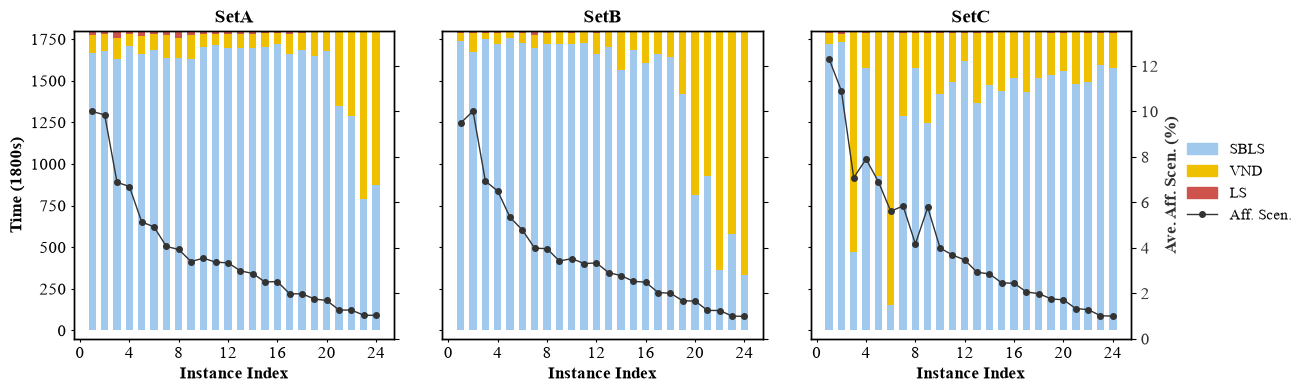

In [11]:
import os
import csv
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 12

def parse_time_log(filepath):
    if not os.path.exists(filepath):
        return None, None
    saa_values, ls_values = [], []
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            lines = [line.strip() for line in f if line.strip()]
            for line in lines:
                parts = line.split(';')
                if len(parts) >= 3:
                    saa_values.append(float(parts[0]))
                    ls_values.append(float(parts[2]))
        if not saa_values: return None, None
        return sum(saa_values)/len(saa_values), sum(ls_values)/len(ls_values)
    except:
        return None, None

def get_category(instance_name):
    if instance_name.endswith("_MD"): return "SetB"
    elif instance_name.endswith("_X"): return "SetC"
    elif instance_name.endswith("_M"): return "SetA"
    return "Unknown"

def main():
    # --- 配置 ---
    folder_name = 'SimHGSTimeLog'
    instance_file = 'instance.txt'
    aff_file = 'result_aff.csv'
    total_time_limit = 1800.0
    colors = ['#A1C9ED', '#EFC000FF', '#CD534CFF'] # 蓝, 橙, 红 0073C2FF
    #colors = ['#A1C9ED', '#FFD885', '#CD534CFF']
    labels = ['SBLS', 'VND', 'LS']
    line_color = '#333333' # 折线颜色：深灰色/黑色
    line_label = 'Aff. Scen.'
    # -----------

    # 1. 读取 AffScenarios 数据
    aff_dict = {}
    if os.path.exists(aff_file):
        with open(aff_file, 'r', encoding='utf-8-sig') as f:
            reader = csv.DictReader(f)
            for row in reader:
                try:
                    name = row['Instance Name']
                    val = float(row['AffScenarios']) if row['AffScenarios'] != 'N/A' else 0
                    aff_dict[name] = val
                except:
                    continue

    # 2. 初始化并处理时间数据
    sets_data = {"SetA": [], "SetB": [], "SetC": []}
    with open(instance_file, 'r', encoding='utf-8') as f:
        instances = [line.strip() for line in f if line.strip()]

    for inst in instances:
        file_path = os.path.join(folder_name, f"{inst}_sol_timeLog.txt")
        avg_saa, avg_ls = parse_time_log(file_path)
        if avg_saa is None: continue
        
        avg_vnd = max(0, total_time_limit - avg_saa - avg_ls)
        category = get_category(inst)
        if category in sets_data:
            sets_data[category].append({
                'name': inst,
                'saa': avg_saa,
                'vnd': avg_vnd,
                'ls': avg_ls,
                'aff': aff_dict.get(inst, 0) # 获取对应的 AffScenarios
            })

    # 3. 绘图
    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
    set_names = ["SetA", "SetB", "SetC"]
    
    # 为了让折线图在三个子图中的比例一致，先计算全局最大值
    all_aff_values = [d['aff'] for s in sets_data.values() for d in s]
    max_aff = max(all_aff_values) * 1.1 if all_aff_values else 10

    twin_axes = [] # 存放右侧坐标轴

    for i, set_name in enumerate(set_names):
        ax = axes[i]
        data = sets_data[set_name]
        if not data: continue

        x_indices = np.arange(1, len(data) + 1)
        saa_vals = np.array([d['saa'] for d in data])
        vnd_vals = np.array([d['vnd'] for d in data])
        ls_vals = np.array([d['ls'] for d in data])
        aff_vals = np.array([d['aff'] for d in data])

        # A. 绘制堆叠柱状图
        ax.bar(x_indices, saa_vals, color=colors[0], label=labels[0], width=0.6)
        ax.bar(x_indices, vnd_vals, bottom=saa_vals, color=colors[1], label=labels[1], width=0.6)
        ax.bar(x_indices, ls_vals, bottom=saa_vals+vnd_vals, color=colors[2], label=labels[2], width=0.6)

        # B. 绘制折线图 (使用 twinx)
        ax_line = ax.twinx()
        lns = ax_line.plot(x_indices, aff_vals, color=line_color, marker='o', 
                           markersize=4, linewidth=1., label=line_label)
        twin_axes.append(ax_line)

        # C. 统一折线图坐标范围
        ax_line.set_ylim(0, max_aff)

        # D. 坐标轴显示逻辑
        if i < 2:
            # 前两个子图隐藏右侧数值
            ax_line.set_yticklabels([])
        else:
            # 只有最右侧子图显示 AffScenarios 坐标和标签
            ax_line.set_ylabel("Ave. Aff. Scen. (%)", fontsize=12, fontweight='bold', color=line_color)
            ax_line.tick_params(axis='y', labelcolor=line_color)

        # 基础样式设置
        ax.set_title(f"{set_name}", fontsize=14, fontweight='bold')
        ax.set_xlabel("Instance Index", fontsize=12, fontweight='bold')
        if i == 0:
            ax.set_ylabel("Time (1800s)", fontsize=12, fontweight='bold')

        ax.set_ylim(-50, 1800)
        ax.tick_params(axis='both', which='both', length=2)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=8, integer=True))

    # 4. 图例处理
    # 提取柱状图句柄
    h_bar = [plt.Rectangle((0,0),1,1, color=c) for c in colors]
    # 提取折线图句柄 (取最后一个即可)
    h_line, _ = twin_axes[-1].get_legend_handles_labels()
    
    all_handles = h_bar + h_line
    all_labels = labels + [line_label]

    # 调整布局留出右侧空间给图例
    plt.subplots_adjust(right=0.88, wspace=0.15) 
    fig.legend(all_handles, all_labels, loc='center left', bbox_to_anchor=(0.91, 0.5), 
               frameon=False, fontsize=11)
    
    # 保存并显示
    plt.savefig("2.Time_Distribution_with_Aff.pdf", dpi=300, bbox_inches='tight')
    print("图片已保存为 Time_Distribution_with_Aff.pdf")
    plt.show()

if __name__ == "__main__":
    main()

开始处理 72 个算例...
CSV 统计结果已保存至 improvement_summary.csv
折线图已保存为 Improvement_Comparison_Subplots_Truncated.pdf


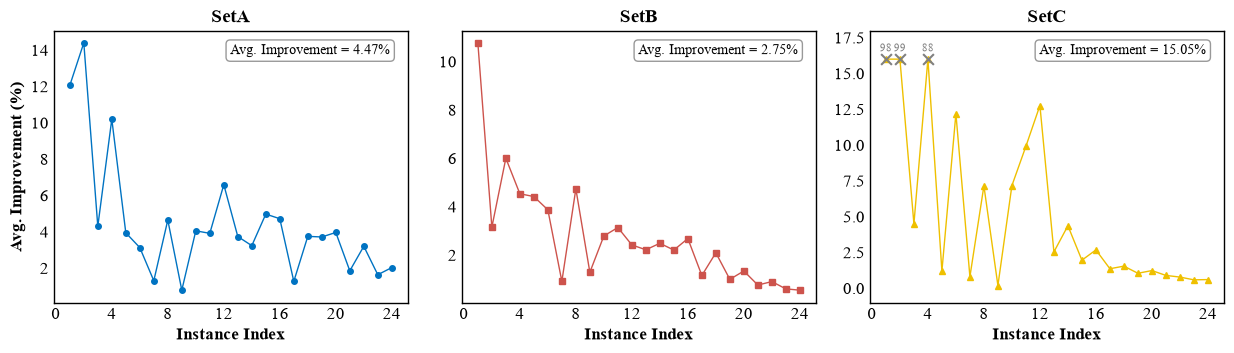

In [12]:
import os
import re
import csv
import statistics
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator

# 设置学术字体 (Times New Roman)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 12

def parse_sol_file(filepath):
    """
    解析 _sol.txt 文件
    返回: (IniSim列表, Cost列表)
    """
    if not os.path.exists(filepath):
        return None, None

    with open(filepath, 'r', encoding='utf-8') as f:
        content = f.read()
        
        # 提取 Cost (SBLS结果)
        costs = re.findall(r'^Cost\s+([\d\.]+)', content, re.MULTILINE)
        # 提取 IniSim (LS结果)
        inisims = re.findall(r'^IniSim\s+([\d\.]+)', content, re.MULTILINE)
        
        # 转换为浮点数
        cost_vals = [float(c) for c in costs]
        inisim_vals = [float(i) for i in inisims]
        
    return inisim_vals, cost_vals

def get_category(instance_name):
    """根据后缀分类算例"""
    if instance_name.endswith("_MD"):
        return "SetB"
    elif instance_name.endswith("_X"):
        return "SetC"
    elif instance_name.endswith("_M"):
        return "SetA"
    else:
        return "Unknown"

def main():
    # --- 配置区域 ---
    base_folder = os.path.join('SampleSize', 'SimHGS1000') 
    instance_file = 'instance.txt'
    output_csv = 'improvement_summary.csv'
    
    styles = {
        'SetA': {'color': '#0073C2FF', 'marker': 'o'},
        'SetB': {'color': '#CD534CFF', 'marker': 's'},#s
        'SetC': {'color': '#EFC000FF', 'marker': '^'}#^
    }
    
    # SetC 的截断阈值
    SETC_THRESHOLD = 16.0 
    # ----------------

    results_csv = [] 
    plot_data = {
        "SetA": [],
        "SetB": [],
        "SetC": []
    }

    # 1. 检查文件
    if not os.path.exists(instance_file):
        print(f"错误: 当前目录下找不到文件 {instance_file}")
        return
    
    if not os.path.exists(base_folder):
        print(f"错误: 找不到数据文件夹 {base_folder}")
        return

    # 2. 读取算例列表
    with open(instance_file, 'r', encoding='utf-8') as f:
        instances = [line.strip() for line in f if line.strip()]

    print(f"开始处理 {len(instances)} 个算例...")

    # 3. 遍历处理每个算例
    for inst in instances:
        file_path = os.path.join(base_folder, f"{inst}_sol.txt")
        inisims, costs = parse_sol_file(file_path)
        
        if not inisims or not costs:
            continue
            
        if len(inisims) != len(costs):
            min_len = min(len(inisims), len(costs))
            inisims = inisims[:min_len]
            costs = costs[:min_len]

        gaps = []
        for ini, c in zip(inisims, costs):
            if abs(ini) > 1e-9:
                gap = (ini - c) / ini * 100.0
                gaps.append(gap)
            else:
                gaps.append(0.0)
        
        if not gaps:
            continue
            
        avg_gap = statistics.mean(gaps)
        results_csv.append([inst, f"{avg_gap:.4f}"])
        
        cat = get_category(inst)
        if cat in plot_data:
            plot_data[cat].append(avg_gap)

    # 4. 输出 CSV 文件
    header = ['Instance index', 'Avg_Improvement_Percentage(%)']
    with open(output_csv, 'w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow(header)
        writer.writerows(results_csv)
    print(f"CSV 统计结果已保存至 {output_csv}")

    # 5. 绘制折线图
    fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.7)) 
    set_names = ["SetA", "SetB", "SetC"]
    
    for i, set_name in enumerate(set_names):
        ax = axes[i]
        original_data = plot_data[set_name]
        style = styles[set_name]
        
        if not original_data:
            ax.set_title(f"{set_name} (No Data)")
            continue
            
        x_indices = np.arange(1, len(original_data) + 1)
        
        # --- 计算该组总体平均值 ---
        overall_avg = statistics.mean(original_data)
        
        # --- 绘图逻辑区分 ---
        if set_name == "SetC":
            # SetC 特殊处理：截断显示
            
            # 1. 准备绘图数据：将超过阈值的数据在图上"压平"到阈值，避免线条射出边界
            plot_values = [min(val, SETC_THRESHOLD) for val in original_data]
            
            # 绘制主要的折线（使用压平后的数据）
            ax.plot(x_indices, plot_values, 
                    color=style['color'], 
                    marker=style['marker'], 
                    markersize=4, 
                    linewidth=1,
                    label=set_name)
            
            # 2. 标记离群点 (超过阈值的数据)
            for idx, val in enumerate(original_data):
                if val > SETC_THRESHOLD:
                    x_pos = x_indices[idx]
                    # 在顶部画红色的 X
                    ax.scatter(x_pos, SETC_THRESHOLD, color='gray', marker='x', s=60, zorder=10)
                    # 在 X 旁边或下方标注具体数值
                    # 稍微调整位置以防遮挡
                    ax.text(x_pos, SETC_THRESHOLD + 1.1, f"{val:.0f}", 
                            color='gray', fontsize=8, ha='center', va='top')#, fontweight='bold'

            # 3. 设置Y轴范围（稍微留出顶部空间给 Avg 标签）
            ax.set_ylim(-1, SETC_THRESHOLD + 2) 
            
            # 4. 在图上显示总体平均值 (Avg. of all)
            # transform=ax.transAxes 意味着使用相对坐标(0-1)，(0.95, 0.95)即右上角
            ax.text(0.95, 0.95, f"Avg. Improvement = {overall_avg:.2f}%", 
                    transform=ax.transAxes, ha='right', va='top', 
                    fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))
            
        else:
            # SetA 和 SetB 正常绘制
            ax.plot(x_indices, original_data, 
                    color=style['color'], 
                    marker=style['marker'], 
                    markersize=4, 
                    linewidth=1,
                    label=set_name)
            
            # 显示总体平均值
            ax.text(0.95, 0.95, f"Avg. Improvement = {overall_avg:.2f}%", 
                    transform=ax.transAxes, ha='right', va='top', 
                    fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

        # --- 通用设置 ---
        ax.set_title(f"{set_name}", fontsize=14, fontweight='bold')
        ax.set_xlabel("Instance Index", fontsize=12, fontweight='bold')
        ax.xaxis.set_major_locator(MaxNLocator(nbins=8, integer=True))
        if i == 0:
            ax.set_ylabel("Avg. Improvement (%)", fontsize=12, fontweight='bold')
        
        #ax.grid(True, linestyle='--', alpha=0.5)
        ax.tick_params(axis='both', which='both', length=0)
    plt.tight_layout()
    plt.savefig("3.Improvement_Comparison_Subplots_Truncated.pdf", dpi=300)
    print("折线图已保存为 Improvement_Comparison_Subplots_Truncated.pdf")
    plt.show()

if __name__ == "__main__":
    main()